# Phase 1 optimizer -- post-hoc smoothing (Section 12.2)

This is one of 7 notebooks in `notebooks/phase1_optimization/`.
Equation/section citations here follow `docs/tt pacing optimizer.md`, the
project's canonical numbering, written as "(design-doc Eq. N)" /
"(design-doc Section N.M)"; display-unit conventions (km/min/km-h⁻¹) are
implemented in `phase_1_0_common.py`'s `as_km`/`as_min`/`as_kmh` helpers, shared
by all 7 notebooks. This one covers
**smooth_posthoc's cheap box-filter-then-resimulate diagnostic mode, stress-tested across the same 6 input-quality tiers as the constrained-re-optimization notebook, plus a direct comparison of the two modes**.

It is fully self-contained: every rider/course/baseline it needs is
rebuilt here via `phase_1_0_common.py` (shared by all 7 split notebooks),
so it runs standalone from a fresh kernel without any other notebook
having run first. Courses used: flat, rolling (synthetic) + Giro10, TdF16, TARA (real). Approx. runtime: ~2-4 min -- no NLP re-solves, just box-filter + resimulation.

In [1]:
import sys
sys.path.insert(0, ".")
import phase_1_0_common as pc

pc.print_rider_summary()

reference_rider        mass= 72.0 kg  CP= 280.0 W  W'= 20.0 kJ  CdA=0.25 m^2  P_max=   900 W
evenepoel_like_rider   mass= 63.5 kg  CP= 425.0 W  W'= 20.0 kJ  CdA=0.21 m^2  P_max=  1400 W
ganna_like_rider       mass= 82.0 kg  CP= 480.0 W  W'= 20.0 kJ  CdA=0.19 m^2  P_max=  1600 W


In [2]:
courses = pc.load_real_courses()
giro10_course, tdf16_course, tara_course = courses["giro10"], courses["tdf16"], courses["tara"]
pc.print_real_course_summary(courses)

Giro 2026 Stage 10   n_nodes= 800  smoothing_length_m=  150 m  mean|grade|= 1.04%  max|grade|=13.20%
TdF 2026 Stage 16    n_nodes= 800  smoothing_length_m=  400 m  mean|grade|= 5.30%  max|grade|=18.53%
TARA 2026 Stage 3    n_nodes= 800  smoothing_length_m=  250 m  mean|grade|= 3.05%  max|grade|=17.56%


Rebuilding all 5 courses' Hermite-Simpson baselines (`build_hs_baseline`)
before the demonstration below -- cheap here since, unlike the
constrained-re-optimization notebook, nothing after this cell re-solves
an NLP.

In [3]:
flat_course = pc.build_flat_course()
rolling_course = pc.build_rolling_course()

opt_hs_flat, res_hs_flat = pc.build_hs_baseline(pc.reference_rider, flat_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_rolling, res_hs_rolling = pc.build_hs_baseline(pc.reference_rider, rolling_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_giro10, res_hs_giro10 = pc.build_hs_baseline(pc.ganna_like_rider, giro10_course, pc.calm_wind, pc.N_INTERVALS_GIRO10)
opt_hs_tdf16, res_hs_tdf16 = pc.build_hs_baseline(pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, pc.N_INTERVALS_TDF16)
opt_hs_tara, res_hs_tara = pc.build_hs_baseline(pc.reference_rider, tara_course, pc.calm_wind, pc.N_INTERVALS_TARA)

## Post-hoc mode (design-doc Section 12.2)

`smooth_posthoc` (design-doc Section 12.2, diagnostic mode) takes a
completely different approach from Eq. 45: it does **not** re-optimize.
It box-filters (moving average, `window_nodes` wide) the unsmoothed
plan's `full_course_power_W` and re-simulates the filtered trace forward
with `ForwardSimulator`. It is cheap (one forward simulation, no NLP
solve) but the result is **not** claimed to be optimal, and -- because
nothing enforces $W'_{bal} \ge 0$ (design-doc Eqs. 31-32) during the filtering step --
it can genuinely violate that path constraint. That is by design: the
point of this mode is to reveal such violations cheaply, not to hide
them or to produce a rideable plan.

The same 6 quality tiers from the constrained-re-optimization notebook
are run through `smooth_posthoc` below, this time perturbing
`full_course_power_W` (the full-course grid, not the post-launch
collocation grid `smooth_constrained` uses).

### 5.1 Flat course

In [4]:
posthoc_results_flat = pc.run_posthoc_tiers(pc.reference_rider, flat_course, pc.calm_wind, res_hs_flat, catastrophic_mode="square", label="flat")

[flat] good         t_finish= 57.0714 min  unsmoothed= 57.1178 min  delta= -2.787 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.595
[flat] acceptable   t_finish= 57.0876 min  unsmoothed= 57.1178 min  delta= -1.814 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.295
[flat] borderline   t_finish= 57.1114 min  unsmoothed= 57.1178 min  delta= -0.387 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.228
[flat] rough        t_finish= 57.1150 min  unsmoothed= 57.1178 min  delta= -0.171 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.215
[flat] very_rough   t_finish= 57.0865 min  unsmoothed= 57.1178 min  delta= -1.880 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.590
[flat] catastrophic t_finish= 47.8591 min  unsmoothed= 57.1178 min  delta=-555.521 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.955


Every tier here shows `w_prime_violated=True`, including the mildest
(`good`). That is expected, not a bug in the perturbation design: the
flat-course optimal baseline already spends W' down to essentially zero
by the finish, by construction (the $W'_{bal} \ge 0$ path constraint,
design-doc Eqs. 31-32, binds exactly there, as `test_slsqp_terminal_w_prime_near_zero` checks) -- so it starts
with zero margin, and *any* re-filtering of it risks dipping into that
floor somewhere. Several tiers even show a **negative** time delta (the
filtered trace appears to finish *faster* than the true optimum). This is
not a real speed-up: it is `ForwardSimulator`'s RK4 integrator not
reducing deliverable power once $W'_{bal}$ is clamped at its floor (a
known approximation noted in `smoothing.py`'s own docstring), so a
`time_total_s` reported alongside `w_prime_violated=True` should not be
read as an achievable time. This is exactly why
`test_smoothing_posthoc_slower_or_flagged_infeasible` accepts
`time_total_s >= unsmoothed_time_total_s OR w_prime_violated` rather than
a strict inequality.

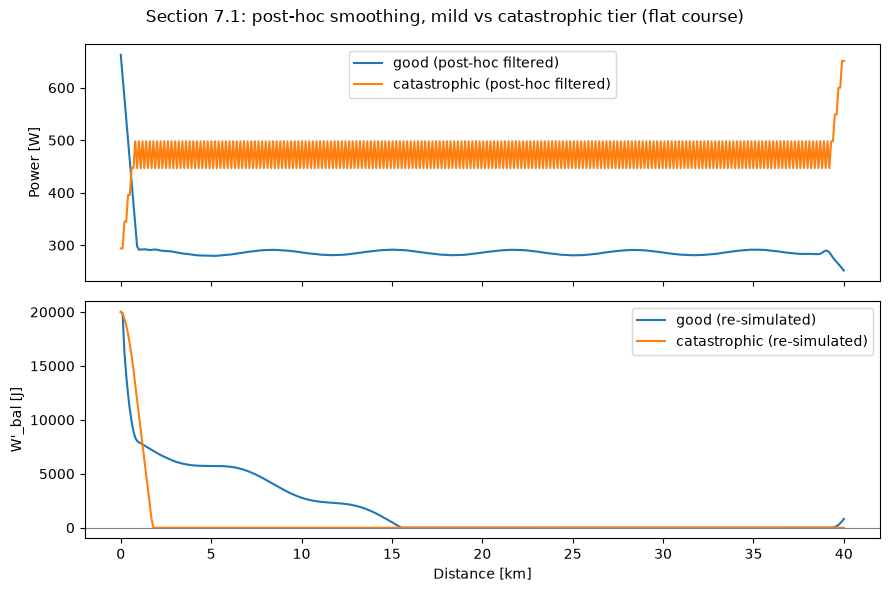

In [5]:
pc.plot_posthoc_extremes(res_hs_flat, flat_course, posthoc_results_flat, "Section 5.1: post-hoc smoothing, mild vs catastrophic tier (flat course)")

### 5.2 Rolling course

In [6]:
posthoc_results_rolling = pc.run_posthoc_tiers(pc.reference_rider, rolling_course, pc.calm_wind, res_hs_rolling, catastrophic_mode="sine", label="rolling")

[rolling] good         t_finish= 34.0056 min  unsmoothed= 34.0558 min  delta= -3.009 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.233
[rolling] acceptable   t_finish= 34.0099 min  unsmoothed= 34.0558 min  delta= -2.752 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.192
[rolling] borderline   t_finish= 34.0070 min  unsmoothed= 34.0558 min  delta= -2.929 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.229
[rolling] rough        t_finish= 34.0140 min  unsmoothed= 34.0558 min  delta= -2.508 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.208
[rolling] very_rough   t_finish= 34.0377 min  unsmoothed= 34.0558 min  delta= -1.084 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.175
[rolling] catastrophic t_finish= 34.0408 min  unsmoothed= 34.0558 min  delta= -0.900 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.237


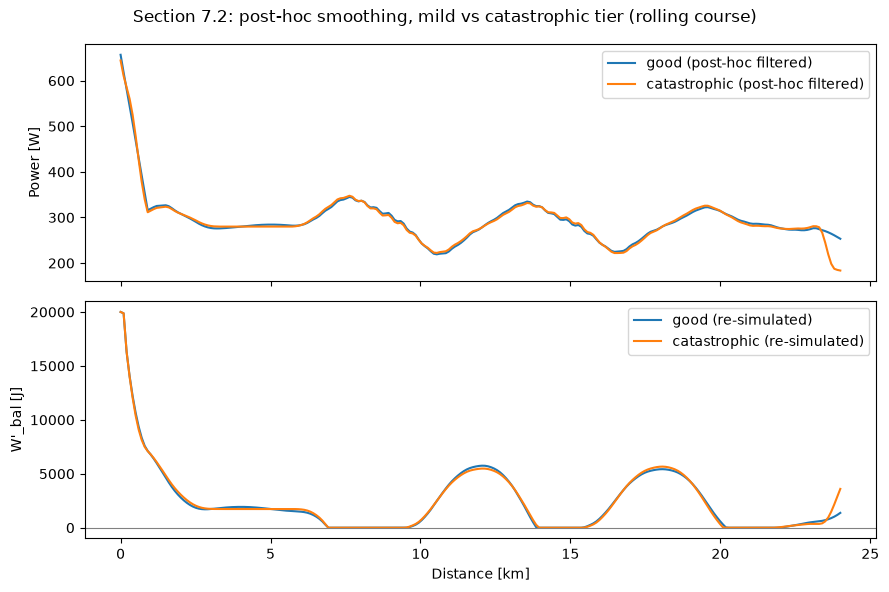

In [7]:
pc.plot_posthoc_extremes(res_hs_rolling, rolling_course, posthoc_results_rolling, "Section 5.2: post-hoc smoothing, mild vs catastrophic tier (rolling course)")

The same pattern holds: every tier's baseline already ends near-zero W',
so every tier flags a violation, and the reported times are not
trustworthy comparisons once that flag is set.

### Constrained re-optimization vs post-hoc smoothing, in one sentence

**Eq. 45 (design-doc Section 12.1, the constrained-re-optimization
notebook)** re-solves the NLP with the slew bound built in, so
$W'_{bal} \ge 0$ (design-doc Eqs. 31-32) is enforced throughout the
solve -- it always returns a genuinely rideable plan, at a time cost that
scales with how much correction the input trace actually needed.
**Design-doc Section 12.2 (this notebook)** only filters and
re-checks after the fact -- it is cheap and useful as a diagnostic ("how
bad would naive smoothing be here?"), but it can return a plan that
violates the rider's own physiology, and its reported time is not
trustworthy when it does.

### 5.3 Giro 2026 Stage 10 (real, flat)

Same 6 tiers as 5.1/5.2, on `res_hs_giro10` (rebuilt above), same
`catastrophic_mode` as the constrained-smoothing notebook's 4.3
(`"square"`).

In [8]:
posthoc_results_giro10 = pc.run_posthoc_tiers(pc.ganna_like_rider, giro10_course, pc.calm_wind, res_hs_giro10, catastrophic_mode="square", label="giro10")

[giro10] good         t_finish= 42.5161 min  unsmoothed= 42.5510 min  delta= -2.092 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.147
[giro10] acceptable   t_finish= 42.5140 min  unsmoothed= 42.5510 min  delta= -2.220 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.131
[giro10] borderline   t_finish= 42.5077 min  unsmoothed= 42.5510 min  delta= -2.596 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.149
[giro10] rough        t_finish= 42.7373 min  unsmoothed= 42.5510 min  delta=+11.178 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.120
[giro10] very_rough   t_finish= 42.6291 min  unsmoothed= 42.5510 min  delta= +4.686 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.129


[giro10] catastrophic t_finish= 35.5740 min  unsmoothed= 42.5510 min  delta=-418.616 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.974


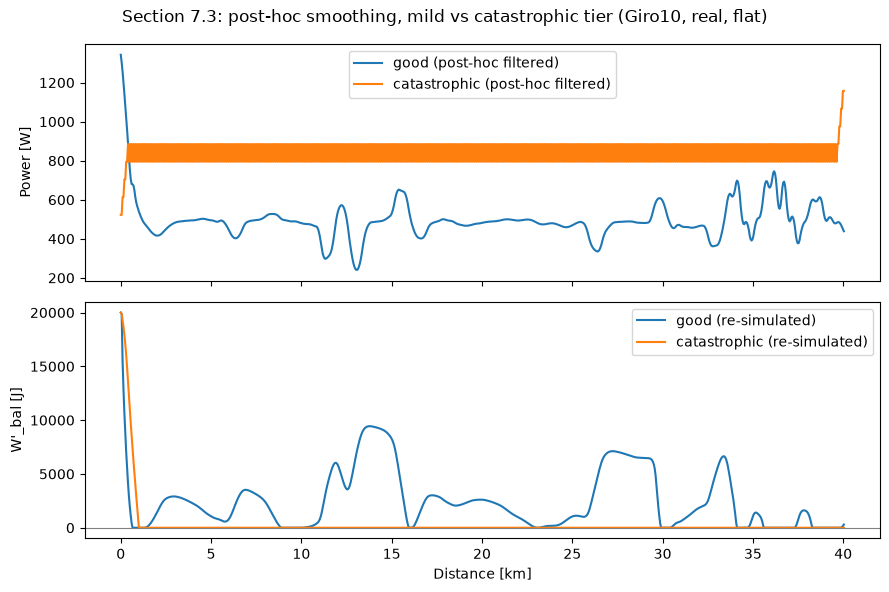

In [9]:
pc.plot_posthoc_extremes(res_hs_giro10, giro10_course, posthoc_results_giro10, "Section 5.3: post-hoc smoothing, mild vs catastrophic tier (Giro10, real, flat)")

### 5.4 TdF 2026 Stage 16 (real, mountainous)

Same 6 tiers, on `res_hs_tdf16` (rebuilt above), same `catastrophic_mode`
as 4.4 (`"sine"`).

In [10]:
posthoc_results_tdf16 = pc.run_posthoc_tiers(pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, res_hs_tdf16, catastrophic_mode="sine", label="tdf16")

[tdf16] good         t_finish= 37.1047 min  unsmoothed= 37.1917 min  delta= -5.218 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.177
[tdf16] acceptable   t_finish= 37.0785 min  unsmoothed= 37.1917 min  delta= -6.793 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.104
[tdf16] borderline   t_finish= 37.2518 min  unsmoothed= 37.1917 min  delta= +3.606 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.109
[tdf16] rough        t_finish= 37.3867 min  unsmoothed= 37.1917 min  delta=+11.702 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.091
[tdf16] very_rough   t_finish= 37.8434 min  unsmoothed= 37.1917 min  delta=+39.105 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.081
[tdf16] catastrophic t_finish= 38.1464 min  unsmoothed= 37.1917 min  delta=+57.285 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.076


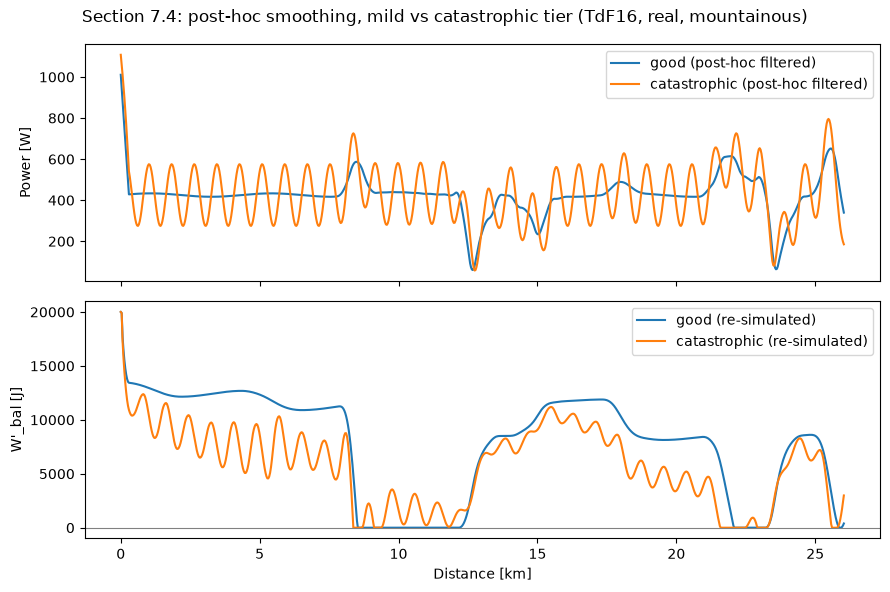

In [11]:
pc.plot_posthoc_extremes(res_hs_tdf16, tdf16_course, posthoc_results_tdf16, "Section 5.4: post-hoc smoothing, mild vs catastrophic tier (TdF16, real, mountainous)")

### 5.5 TARA 2026 Stage 3 (real, rolling/TTT)

Same 6 tiers, on `res_hs_tara` (rebuilt above), same `catastrophic_mode`
as 4.5 (`"sine"`).

In [12]:
posthoc_results_tara = pc.run_posthoc_tiers(pc.reference_rider, tara_course, pc.calm_wind, res_hs_tara, catastrophic_mode="sine", label="tara")

[tara] good         t_finish= 44.2282 min  unsmoothed= 45.4841 min  delta=-75.354 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.145
[tara] acceptable   t_finish= 44.2419 min  unsmoothed= 45.4841 min  delta=-74.533 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.101
[tara] borderline   t_finish= 44.5105 min  unsmoothed= 45.4841 min  delta=-58.417 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.110
[tara] rough        t_finish= 44.5935 min  unsmoothed= 45.4841 min  delta=-53.437 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.110
[tara] very_rough   t_finish= 44.8793 min  unsmoothed= 45.4841 min  delta=-36.289 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.070
[tara] catastrophic t_finish= 45.0297 min  unsmoothed= 45.4841 min  delta=-27.266 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.076


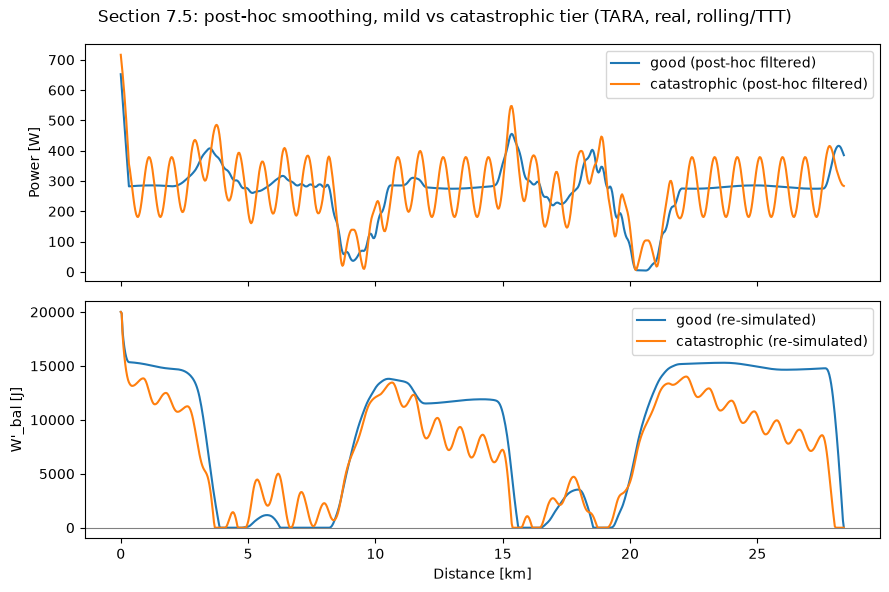

In [13]:
pc.plot_posthoc_extremes(res_hs_tara, tara_course, posthoc_results_tara, "Section 5.5: post-hoc smoothing, mild vs catastrophic tier (TARA, real, rolling/TTT)")

As in 5.1/5.2, every tier's baseline on all three real courses already
spends W' down to essentially zero by the finish (all five `res_hs_*`
results satisfy the same terminal-W'-near-zero property), so every tier
here is expected to flag `w_prime_violated=True` regardless of terrain --
the mechanism the "constrained re-optimization vs post-hoc smoothing"
comparison above describes is not specific to synthetic courses. Even the mildest (`good`) tier already
leaves a non-trivial fraction of the re-simulated course sitting at the
W'=0 floor (14.5-17.7% across the three real courses). The `catastrophic`
tier's effect varies far more by course than tier severity alone would
suggest: Giro10 ends up almost entirely floored (97.4%), while TdF16 and
TARA -- despite a far rougher input -- land at just 7.6%, even *below*
their own `good` tier. That non-monotonicity echoes the same
tier-severity-doesn't-predict-outcome pattern the constrained-smoothing
notebook's TARA subsection documents, now showing up in the purely-filtered post-hoc
mode too.